# 02.04 - PANDAS

<a target="_blank" href="https://colab.research.google.com/github/rramosp/ai4eng.v1/blob/main/content/NOTES%2002.04%20-%20PANDAS.ipynb"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!wget --no-cache -O init.py -q https://raw.githubusercontent.com/rramosp/ai4eng.v1/main/content/init.py
import init; init.init(force_download=False); init.get_weblink()

replicating local resources


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

## `pandas` is mostly about manipulating tables of data

see this cheat sheet: https://pandas.pydata.org/Pandas_Cheat_Sheet.pdf


## Pandas main object is a `DataFrame`

- can read .csv, .excel, etc.


In [3]:
!head local/data/internet_facebook.dat

# Pais,Uso_Internet,Uso_Facebook
Argentina,49.40,30.53
Australia,80.60,46.01
Belgium,67.30,36.98
Brazil,37.76,4.39
Canada,72.30,52.08
Chile,50.90,46.14
China,22.40,0.05
Colombia,38.80,25.90
Egypt,12.90,5.68


In [4]:
!wc local/data/weather_data_austin_2010.csv

  8760  17519 254046 local/data/weather_data_austin_2010.csv


In [5]:
df = pd.read_csv('local/data/internet_facebook.dat', index_col='# Pais')
df

,Uso_Internet,Uso_Facebook
# Pais,,
Argentina,49.40,30.53
Australia,80.60,46.01
Belgium,67.30,36.98
Brazil,37.76,4.39
Canada,72.30,52.08
Chile,50.90,46.14
China,22.40,0.05
Colombia,38.80,25.90
Egypt,12.90,5.68


In [ ]:
df.head()

,Uso_Internet,Uso_Facebook
# Pais,,
Argentina,49.40,30.53
Australia,80.60,46.01
Belgium,67.30,36.98
Brazil,37.76,4.39
Canada,72.30,52.08


In [6]:
df.tail()

,Uso_Internet,Uso_Facebook
# Pais,,
Thailand,20.50,10.29
Turkey,35.00,31.91
USA,77.33,46.98
UK,70.18,45.97
Venezuela,25.50,28.64


In [7]:
df.columns

Index(['Uso_Internet', 'Uso_Facebook'], dtype='object')

In [8]:
df.index

Index(['Argentina', 'Australia', 'Belgium', 'Brazil', 'Canada', 'Chile',
       'China', 'Colombia', 'Egypt', 'France', 'Germany', 'Hong_Kong', 'India',
       'Indonesia', 'Italy', 'Japan', 'Malaysia', 'Mexico', 'Netherlands',
       'Peru', 'Philippines', 'Poland', 'Russia', 'Saudi_Arabia',
       'South_Africa', 'Spain', 'Sweden', 'Taiwan', 'Thailand', 'Turkey',
       'USA', 'UK', 'Venezuela'],
      dtype='object', name='# Pais')

**fix the index name**

In [9]:
df.index.name="Pais"
df.head()

,Uso_Internet,Uso_Facebook
Pais,,
Argentina,49.40,30.53
Australia,80.60,46.01
Belgium,67.30,36.98
Brazil,37.76,4.39
Canada,72.30,52.08


In [10]:
df.describe()

,Uso_Internet,Uso_Facebook
count,33.000000,33.000000
mean,46.890000,24.668182
std,24.456421,16.511662
min,7.100000,0.050000
25%,24.900000,11.650000
50%,49.400000,25.900000
75%,67.300000,37.770000
max,82.900000,52.330000


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 33 entries, Argentina to Venezuela
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Uso_Internet  33 non-null     float64
 1   Uso_Facebook  33 non-null     float64
dtypes: float64(2)
memory usage: 792.0+ bytes


**a dataframe is made of `Series`**. Observe that each series has **its own type**

In [12]:
s1 = df["Uso_Internet"]
type(s1)

pandas.core.series.Series

In [13]:
s1

,Uso_Internet
Pais,
Argentina,49.40
Australia,80.60
Belgium,67.30
Brazil,37.76
Canada,72.30
Chile,50.90
China,22.40
Colombia,38.80
Egypt,12.90


if the column name is not too fancy (empy spaces, accents, etc.) we can use columns names as python syntax.

In [14]:
df.Uso_Facebook

,Uso_Facebook
Pais,
Argentina,30.53
Australia,46.01
Belgium,36.98
Brazil,4.39
Canada,52.08
Chile,46.14
China,0.05
Colombia,25.90
Egypt,5.68


## DataFrame indexing

is **NOT** exactly like numpy

- first index
    - if string refers to columns
    - if `Series` of booleans is used as a filter
    
- for selecting columns:
    - use `.loc` to select by Index
    - use `.iloc` to select by position   

In [15]:
df["Colombia"]

KeyError: 'Colombia'

In [16]:
df.loc["Colombia"]

,Colombia
Uso_Internet,38.8
Uso_Facebook,25.9


Index semantics is exact!!

In [17]:
df.loc["Colombia":"Spain"]

,Uso_Internet,Uso_Facebook
Pais,,
Colombia,38.8,25.90
Egypt,12.9,5.68
France,65.7,32.91
Germany,67.0,14.07
Hong_Kong,69.5,52.33
India,7.1,1.52
Indonesia,10.5,13.49
Italy,48.8,30.62
Japan,73.8,2.00


In [18]:
df.iloc[10:15]

,Uso_Internet,Uso_Facebook
Pais,,
Germany,67.0,14.07
Hong_Kong,69.5,52.33
India,7.1,1.52
Indonesia,10.5,13.49
Italy,48.8,30.62


filtering

In [19]:
df[df.Uso_Internet>80]

,Uso_Internet,Uso_Facebook
Pais,,
Australia,80.6,46.01
Netherlands,82.9,20.54
Sweden,80.7,44.72


combined conditions

In [20]:
df[(df.Uso_Internet>50)&(df.Uso_Facebook>50)]

,Uso_Internet,Uso_Facebook
Pais,,
Canada,72.3,52.08
Hong_Kong,69.5,52.33


In [21]:
df[(df.Uso_Internet>50)|(df.Uso_Facebook>50)]

,Uso_Internet,Uso_Facebook
Pais,,
Australia,80.60,46.01
Belgium,67.30,36.98
Canada,72.30,52.08
Chile,50.90,46.14
France,65.70,32.91
Germany,67.00,14.07
Hong_Kong,69.50,52.33
Japan,73.80,2.00
Malaysia,62.80,37.77


## Managing data

    
    
observe csv structure:
- missing column name
- missing data

In [22]:
!head local/data/comptagevelo2009.csv

Date,,Berri1,Maisonneuve_1,Maisonneuve_2,Brébeuf
01/01/2009,00:00,29,20,35,
02/01/2009,00:00,19,3,22,
03/01/2009,00:00,24,12,22,
04/01/2009,00:00,24,8,15,
05/01/2009,00:00,120,111,141,
06/01/2009,00:00,261,146,236,
07/01/2009,00:00,60,33,80,
08/01/2009,00:00,24,14,14,
09/01/2009,00:00,35,20,32,


In [23]:
d = pd.read_csv("local/data/comptagevelo2009.csv")
d

,Date,Unnamed: 1,Berri1,Maisonneuve_1,Maisonneuve_2,Brébeuf
0,01/01/2009,00:00,29,20,35,NaN
1,02/01/2009,00:00,19,3,22,NaN
2,03/01/2009,00:00,24,12,22,NaN
3,04/01/2009,00:00,24,8,15,NaN
4,05/01/2009,00:00,120,111,141,NaN
...,...,...,...,...,...,...
360,27/12/2009,00:00,66,29,52,0.0
361,28/12/2009,00:00,61,41,99,0.0
362,29/12/2009,00:00,89,52,115,0.0
363,30/12/2009,00:00,76,43,115,0.0


In [24]:
d.columns, d.shape


(Index(['Date', 'Unnamed: 1', 'Berri1', 'Maisonneuve_1', 'Maisonneuve_2',
        'Brébeuf'],
       dtype='object'),
 (365, 6))

numerical features

In [25]:
d.describe()

,Berri1,Maisonneuve_1,Maisonneuve_2,Brébeuf
count,365.000000,365.000000,365.000000,178.000000
mean,2032.200000,1060.252055,2093.169863,2576.359551
std,1878.879799,1079.533086,1854.368523,2484.004743
min,0.000000,0.000000,0.000000,0.000000
25%,194.000000,90.000000,228.000000,0.000000
50%,1726.000000,678.000000,1686.000000,1443.500000
75%,3540.000000,1882.000000,3520.000000,4638.000000
max,6626.000000,4242.000000,6587.000000,7575.000000


In [26]:
d["Berri1"].head()

,Berri1
0,29
1,19
2,24
3,24
4,120


In [27]:
d["Unnamed: 1"].unique()


array(['00:00'], dtype=object)

In [28]:
d["Berri1"].unique()


array([  29,   19,   24,  120,  261,   60,   35,   81,  318,  105,  168,
        145,  131,   93,   25,   52,  136,  147,  109,  172,  148,   15,
        209,   92,  110,   14,  158,  179,  122,   95,  185,   82,  190,
        228,  306,  188,   98,  139,  258,  304,  326,  134,  125,   96,
         65,  123,  129,  154,  239,  198,   32,   67,  157,  164,  300,
        176,  195,  310,    7,  366,  234,  132,  203,  298,  541,  525,
        871,  592,  455,  446,  441,  266,  189,  343,  292,  355,  245,
          0,  445, 1286, 1178, 2131, 2709,  752, 1886, 2069, 3132, 3668,
       1368, 4051, 2286, 3519, 3520, 1925, 2125, 2662, 4403, 4338, 2757,
        970, 2767, 1493,  728, 3982, 4742, 5278, 2344, 4094,  784, 1048,
       2442, 3686, 3042, 5728, 3815, 3540, 4775, 4434, 4363, 2075, 2338,
       1387, 2063, 2031, 3274, 4325, 5430, 6028, 3876, 2742, 4973, 1125,
       3460, 4449, 3576, 4027, 4313, 3182, 5668, 6320, 2397, 2857, 2590,
       3234, 5138, 5799, 4911, 4333, 3680, 1536, 30

In [29]:
d["Berri1"].dtype, d["Date"].dtype, d["Unnamed: 1"].dtype


(dtype('int64'), dtype('O'), dtype('O'))

In [30]:
d.index


RangeIndex(start=0, stop=365, step=1)

## Fixing data

observe we set one column as the index one, and we **convert** it to date object type

In [31]:
d.Date

,Date
0,01/01/2009
1,02/01/2009
2,03/01/2009
3,04/01/2009
4,05/01/2009
...,...
360,27/12/2009
361,28/12/2009
362,29/12/2009
363,30/12/2009


In [32]:
d.index = pd.to_datetime(d.Date)
del(d["Date"])
del(d["Unnamed: 1"])
d.head()

ValueError: time data "13/01/2009" doesn't match format "%m/%d/%Y", at position 12. You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.

In [33]:
d.index

RangeIndex(start=0, stop=365, step=1)

let's fix columns names

In [34]:
d.columns=["Berri", "Mneuve1", "Mneuve2", "Brebeuf"]
d.head()

ValueError: Length mismatch: Expected axis has 6 elements, new values have 4 elements

In [35]:
for col in d.columns:
    print (col, np.sum(pd.isnull(d[col])))

Date 0
Unnamed: 1 0
Berri1 0
Maisonneuve_1 0
Maisonneuve_2 0
Brébeuf 187


In [36]:
d.shape

(365, 6)

In [37]:
d['Brebeuf'].describe()

KeyError: 'Brebeuf'

In [38]:
plt.hist(d.Brebeuf, bins=30);

AttributeError: 'DataFrame' object has no attribute 'Brebeuf'

**fix missing**!!!

In [39]:
d.Brebeuf.fillna(d.Brebeuf.mean(), inplace=True)


AttributeError: 'DataFrame' object has no attribute 'Brebeuf'

In [40]:
d['Brebeuf'].describe()

KeyError: 'Brebeuf'

In [41]:
plt.hist(d.Brebeuf, bins=30);

AttributeError: 'DataFrame' object has no attribute 'Brebeuf'

In [42]:
d

,Date,Unnamed: 1,Berri1,Maisonneuve_1,Maisonneuve_2,Brébeuf
0,01/01/2009,00:00,29,20,35,NaN
1,02/01/2009,00:00,19,3,22,NaN
2,03/01/2009,00:00,24,12,22,NaN
3,04/01/2009,00:00,24,8,15,NaN
4,05/01/2009,00:00,120,111,141,NaN
...,...,...,...,...,...,...
360,27/12/2009,00:00,66,29,52,0.0
361,28/12/2009,00:00,61,41,99,0.0
362,29/12/2009,00:00,89,52,115,0.0
363,30/12/2009,00:00,76,43,115,0.0


let's make sure it is sorted

In [43]:
d.sort_index(inplace=True)
d.head()

,Date,Unnamed: 1,Berri1,Maisonneuve_1,Maisonneuve_2,Brébeuf
0,01/01/2009,00:00,29,20,35,NaN
1,02/01/2009,00:00,19,3,22,NaN
2,03/01/2009,00:00,24,12,22,NaN
3,04/01/2009,00:00,24,8,15,NaN
4,05/01/2009,00:00,120,111,141,NaN


## Filtering

In [44]:
d[d.Berri>6000]


AttributeError: 'DataFrame' object has no attribute 'Berri'

In [45]:
d[(d.Berri>6000) & (d.Brebeuf<7000)]


AttributeError: 'DataFrame' object has no attribute 'Berri'

## Locating

In [46]:
d[d.Berri>5500].sort_index(axis=0)


AttributeError: 'DataFrame' object has no attribute 'Berri'

In [47]:
d.iloc[100:110]


,Date,Unnamed: 1,Berri1,Maisonneuve_1,Maisonneuve_2,Brébeuf
100,11/04/2009,00:00,0,0,0,NaN
101,12/04/2009,00:00,0,0,0,NaN
102,13/04/2009,00:00,0,0,0,NaN
103,14/04/2009,00:00,0,0,0,NaN
104,15/04/2009,00:00,0,0,0,NaN
105,16/04/2009,00:00,0,0,0,NaN
106,17/04/2009,00:00,1286,820,1436,NaN
107,18/04/2009,00:00,1178,667,826,NaN
108,19/04/2009,00:00,2131,1155,1426,NaN
109,20/04/2009,00:00,2709,1697,2646,NaN


**dates as INDEX have special semantics**

In [48]:
d.loc["2009-10-01":"2009-10-10"]


,Date,Unnamed: 1,Berri1,Maisonneuve_1,Maisonneuve_2,Brébeuf


can do sorting across any criteria

In [49]:
d.sort_values(by="Berri").head()


KeyError: 'Berri'

and chain operations

In [50]:
d.sort_values(by="Berri").loc["2009-10-01":"2009-10-10"]


KeyError: 'Berri'

## Time series operations

In [51]:
d.rolling(3).mean().head(10)


DataError: Cannot aggregate non-numeric type: object

In [52]:
d.index = d.index + pd.Timedelta("5m")
d.head()

TypeError: Concatenation operation is not implemented for NumPy arrays, use np.concatenate() instead. Please do not rely on this error; it may not be given on all Python implementations.

In [53]:
d.shift(freq=pd.Timedelta(days=365)).head()


NotImplementedError: This method is only implemented for DatetimeIndex, PeriodIndex and TimedeltaIndex; Got type RangeIndex

## Downsampling

In [54]:
d.resample(pd.Timedelta("2d")).first().head()


TypeError: Only valid with DatetimeIndex, TimedeltaIndex or PeriodIndex, but got an instance of 'RangeIndex'

In [55]:
d.resample(pd.Timedelta("2d")).mean().head()


TypeError: Only valid with DatetimeIndex, TimedeltaIndex or PeriodIndex, but got an instance of 'RangeIndex'

## Upsampling

In [56]:
d.resample(pd.Timedelta("12h")).first().head()


TypeError: Only valid with DatetimeIndex, TimedeltaIndex or PeriodIndex, but got an instance of 'RangeIndex'

In [57]:
d.resample(pd.Timedelta("12h")).fillna(method="pad").head()


TypeError: Only valid with DatetimeIndex, TimedeltaIndex or PeriodIndex, but got an instance of 'RangeIndex'

## Building Dataframes from other structures

In [58]:

a = np.random.randint(10,size=(20,5))
a

array([[1, 5, 1, 1, 7],
       [6, 9, 0, 6, 3],
       [1, 1, 1, 9, 6],
       [7, 2, 4, 1, 9],
       [7, 6, 3, 0, 5],
       [5, 0, 8, 4, 8],
       [3, 8, 9, 8, 9],
       [1, 5, 6, 7, 6],
       [4, 8, 0, 3, 8],
       [3, 3, 6, 6, 3],
       [3, 3, 3, 0, 7],
       [2, 3, 1, 3, 8],
       [3, 0, 3, 1, 7],
       [1, 7, 6, 6, 0],
       [0, 5, 3, 3, 7],
       [8, 8, 2, 8, 4],
       [8, 5, 6, 8, 2],
       [9, 1, 6, 2, 4],
       [4, 8, 5, 5, 3],
       [3, 6, 7, 5, 7]])

In [59]:
k = pd.DataFrame(a, columns=["uno", "dos", "tres", "cuatro", "cinco"], index=range(10,10+len(a)))
k

,uno,dos,tres,cuatro,cinco
10,1,5,1,1,7
11,6,9,0,6,3
12,1,1,1,9,6
13,7,2,4,1,9
14,7,6,3,0,5
15,5,0,8,4,8
16,3,8,9,8,9
17,1,5,6,7,6
18,4,8,0,3,8
19,3,3,6,6,3


## `.values` access the underlying `numpy` structure

In [60]:
d.values

array([['01/01/2009', '00:00', 29, 20, 35, nan],
       ['02/01/2009', '00:00', 19, 3, 22, nan],
       ['03/01/2009', '00:00', 24, 12, 22, nan],
       ...,
       ['29/12/2009', '00:00', 89, 52, 115, 0.0],
       ['30/12/2009', '00:00', 76, 43, 115, 0.0],
       ['31/12/2009', '00:00', 53, 46, 112, 0.0]], dtype=object)

## some out-of-the-box plotting

but recall that we always can do custom plotting

<Axes: >

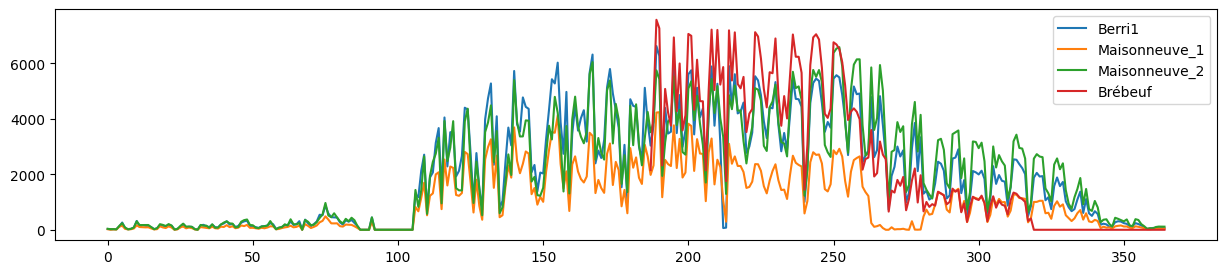

In [61]:
d.plot(figsize=(15,3))


In [62]:
plt.figure(figsize=(15,3))
plt.plot(d.Berri)

AttributeError: 'DataFrame' object has no attribute 'Berri'

<Figure size 1500x300 with 0 Axes>

In [63]:
d.Berri.cumsum().plot()


AttributeError: 'DataFrame' object has no attribute 'Berri'

In [64]:
plt.scatter(d.Berri, d.Brebeuf)


AttributeError: 'DataFrame' object has no attribute 'Berri'

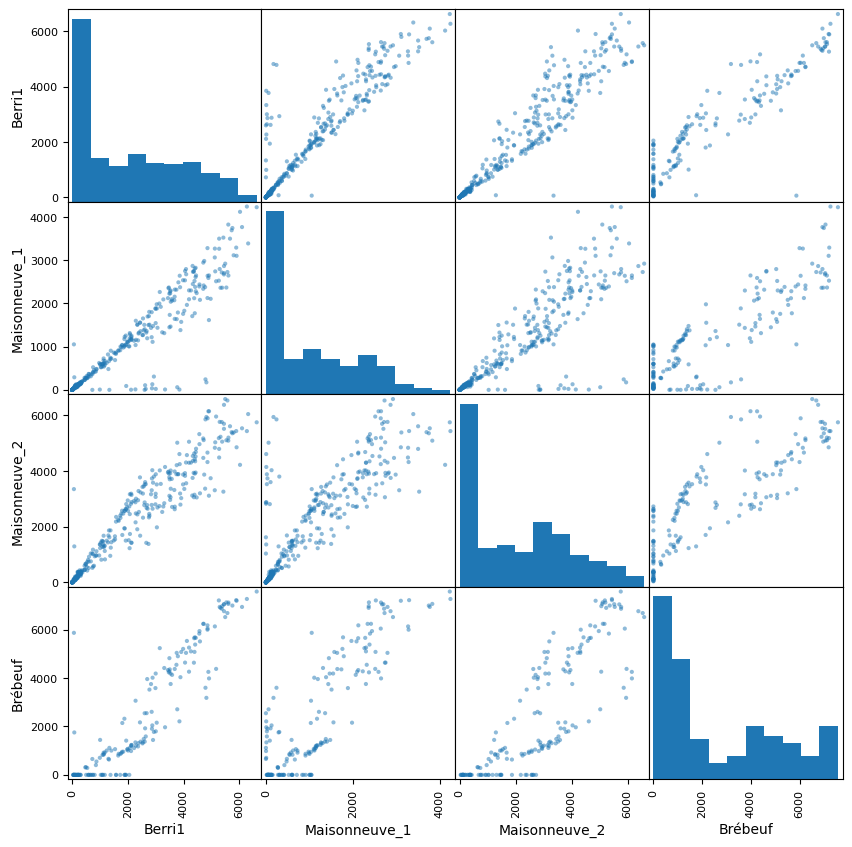

In [65]:
pd.plotting.scatter_matrix(d, figsize=(10,10));

## Grouping

In [66]:

d["month"] = [i.month for i in d.index]
d.head()

AttributeError: 'int' object has no attribute 'month'

In [67]:
d.groupby("month").max()


KeyError: 'month'

In [68]:
d.groupby("month").count()


KeyError: 'month'

## Time series

observe we can **establish at load time** many thing if the dataset is relatively clean

In [69]:

tiempo=pd.read_csv('local/data/weather_data_austin_2010.csv',parse_dates=['Date'], dayfirst=True ,index_col='Date')
tiempo

/tmp/ipykernel_562/3700229720.py:1: UserWarning: Parsing dates in %Y%m%d %H:%M format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  tiempo=pd.read_csv('local/data/weather_data_austin_2010.csv',parse_dates=['Date'], dayfirst=True ,index_col='Date')


,Temperature,DewPoint,Pressure
Date,,,
2010-01-01 00:00:00,46.2,37.5,1.0
2010-01-01 01:00:00,44.6,37.1,1.0
2010-01-01 02:00:00,44.1,36.9,1.0
2010-01-01 03:00:00,43.8,36.9,1.0
2010-01-01 04:00:00,43.5,36.8,1.0
...,...,...,...
2010-12-31 19:00:00,51.1,38.1,1.0
2010-12-31 20:00:00,49.0,37.9,1.0
2010-12-31 21:00:00,47.9,37.9,1.0


In [70]:
tiempo.loc['2010-08-01':'2010-10-30']


,Temperature,DewPoint,Pressure
Date,,,
2010-08-01 00:00:00,79.0,70.8,1.0
2010-08-01 01:00:00,77.4,71.2,1.0
2010-08-01 02:00:00,76.4,71.3,1.0
2010-08-01 03:00:00,75.7,71.4,1.0
2010-08-01 04:00:00,75.1,71.4,1.0
...,...,...,...
2010-10-30 19:00:00,65.4,53.6,1.0
2010-10-30 20:00:00,63.6,53.9,1.0
2010-10-30 21:00:00,62.2,53.8,1.0


In [71]:
tiempo.loc['2010-06'].head()


,Temperature,DewPoint,Pressure
Date,,,
2010-06-01 00:00:00,74.0,67.9,1.0
2010-06-01 01:00:00,72.6,68.0,1.0
2010-06-01 02:00:00,72.0,67.9,1.0
2010-06-01 03:00:00,71.6,67.9,1.0
2010-06-01 04:00:00,71.1,67.7,1.0


In [72]:
tiempo.sample(10)


,Temperature,DewPoint,Pressure
Date,,,
2010-11-05 23:00:00,59.1,52.6,1.0
2010-11-29 22:00:00,52.8,43.6,1.0
2010-01-29 10:00:00,51.0,40.5,1.0
2010-03-23 05:00:00,54.7,49.1,1.0
2010-01-06 04:00:00,43.9,37.1,1.0
2010-05-30 14:00:00,87.0,67.4,1.0
2010-11-29 14:00:00,65.9,43.9,1.0
2010-11-26 02:00:00,51.5,44.8,1.0
2010-08-07 13:00:00,93.4,68.4,1.0


In [73]:
tiempo.sample(frac=0.01)


,Temperature,DewPoint,Pressure
Date,,,
2010-05-10 03:00:00,67.3,63.0,1.0
2010-03-31 12:00:00,69.3,52.4,1.0
2010-06-19 12:00:00,87.7,69.5,1.0
2010-01-22 02:00:00,45.4,38.5,1.0
2010-01-25 21:00:00,50.3,40.1,1.0
...,...,...,...
2010-09-30 04:00:00,65.5,60.2,1.0
2010-09-29 00:00:00,69.6,61.4,1.0
2010-02-24 22:00:00,54.4,44.6,1.0


## Resampling

In [74]:
tiempo.head()


,Temperature,DewPoint,Pressure
Date,,,
2010-01-01 00:00:00,46.2,37.5,1.0
2010-01-01 01:00:00,44.6,37.1,1.0
2010-01-01 02:00:00,44.1,36.9,1.0
2010-01-01 03:00:00,43.8,36.9,1.0
2010-01-01 04:00:00,43.5,36.8,1.0


In [75]:
tiempo.resample("5d").mean().head()

,Temperature,DewPoint,Pressure
Date,,,
2010-01-01,49.720833,38.092500,1.0
2010-01-06,49.449167,37.575000,1.0
2010-01-11,49.222500,37.603333,1.0
2010-01-16,49.441667,37.650000,1.0
2010-01-21,50.683333,39.309167,1.0


In [76]:
tiempo.resample("5d").mean().head()


,Temperature,DewPoint,Pressure
Date,,,
2010-01-01,49.720833,38.092500,1.0
2010-01-06,49.449167,37.575000,1.0
2010-01-11,49.222500,37.603333,1.0
2010-01-16,49.441667,37.650000,1.0
2010-01-21,50.683333,39.309167,1.0


In [77]:
tiempo.resample("5d").mean().head()


,Temperature,DewPoint,Pressure
Date,,,
2010-01-01,49.720833,38.092500,1.0
2010-01-06,49.449167,37.575000,1.0
2010-01-11,49.222500,37.603333,1.0
2010-01-16,49.441667,37.650000,1.0
2010-01-21,50.683333,39.309167,1.0


In [78]:
tiempo.resample("30min").mean()[:15]


,Temperature,DewPoint,Pressure
Date,,,
2010-01-01 00:00:00,46.2,37.5,1.0
2010-01-01 00:30:00,NaN,NaN,NaN
2010-01-01 01:00:00,44.6,37.1,1.0
2010-01-01 01:30:00,NaN,NaN,NaN
2010-01-01 02:00:00,44.1,36.9,1.0
2010-01-01 02:30:00,NaN,NaN,NaN
2010-01-01 03:00:00,43.8,36.9,1.0
2010-01-01 03:30:00,NaN,NaN,NaN
2010-01-01 04:00:00,43.5,36.8,1.0


In [79]:

subt=tiempo.between_time(start_time='1:00',end_time='12:00')
subt

,Temperature,DewPoint,Pressure
Date,,,
2010-01-01 01:00:00,44.6,37.1,1.0
2010-01-01 02:00:00,44.1,36.9,1.0
2010-01-01 03:00:00,43.8,36.9,1.0
2010-01-01 04:00:00,43.5,36.8,1.0
2010-01-01 05:00:00,43.0,36.5,1.0
...,...,...,...
2010-12-31 08:00:00,42.5,36.1,1.0
2010-12-31 09:00:00,46.0,37.7,1.0
2010-12-31 10:00:00,49.4,38.0,1.0


In [80]:
tiempo.index.weekday


Index([4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
       ...
       4, 4, 4, 4, 4, 4, 4, 4, 4, 4],
      dtype='int32', name='Date', length=8759)

In [81]:
tiempo.index.month


Index([ 1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
       ...
       12, 12, 12, 12, 12, 12, 12, 12, 12, 12],
      dtype='int32', name='Date', length=8759)

In [82]:
tiempo.index.day


Index([ 1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
       ...
       31, 31, 31, 31, 31, 31, 31, 31, 31, 31],
      dtype='int32', name='Date', length=8759)

<Axes: xlabel='Date'>

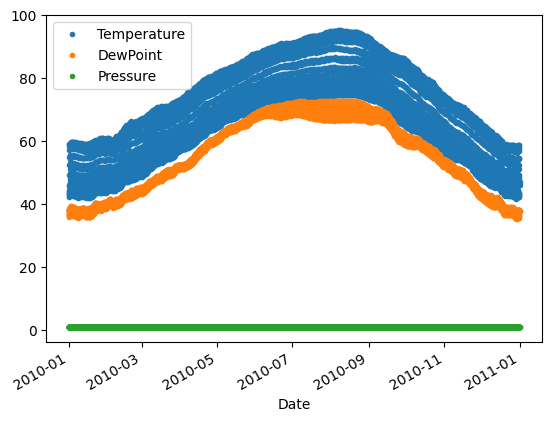

In [83]:
tiempo.plot(style='.')


In [84]:
tiempo['2010-01'].plot()

KeyError: '2010-01'

In [85]:
tiempo['2010-01-04'].plot()

KeyError: '2010-01-04'

## Rolling operations

In [86]:
import pandas as pd
### permite obtener data frames directamente de internet
!pip install yfinance

In [87]:
import yfinance as yf


In [88]:
#define the ticker symbol
tickerSymbol = 'MSFT'

#get data on this ticker
tickerData = yf.Ticker(tickerSymbol)

#get the historical prices for this ticker
gs = tickerData.history(period='1d', start='2010-1-1', end='2020-1-25')

#see your data
gs

ValueError: Setting period, start and end is nonsense. Set maximum 2 of them.

In [89]:
gs.Close.rolling(10).mean().head(20)


NameError: name 'gs' is not defined

In [90]:
plt.figure(figsize=(20,3))
plt.plot(gs.Close)
plt.plot(gs.Close.rolling(50).mean())


NameError: name 'gs' is not defined

<Figure size 2000x300 with 0 Axes>

In [91]:
plt.figure(figsize=(20,3))
plt.plot(gs.iloc[:400].Close, label="original")
plt.plot(gs.iloc[:400].Close.rolling(50).mean(), label="rolling")
plt.plot(gs.iloc[:400].Close.rolling(50, center=True).mean(), label="center")
plt.legend();

NameError: name 'gs' is not defined

<Figure size 2000x300 with 0 Axes>

In [92]:
plt.figure(figsize=(20,3))
plt.plot(gs.iloc[:400].Close.rolling(10).mean())


NameError: name 'gs' is not defined

<Figure size 2000x300 with 0 Axes>